In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
FILE_PATH = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/journal_storage_multiprocess.csv'

In [9]:
df = pd.read_csv(FILE_PATH)
params = [name for name in df.columns if 'Param' in name]
params_norm =  [name + ' norm' for name in df.columns if 'Param' in name]

In [10]:
for param in params:
    df[param + ' norm'] = (df[param] - df[param].min()) / (df[param].max() - df[param].min())

df = df.sort_values(by='Value', ascending=False)

Param A_ltd            1.852294
Param C                1.088562
Param Lr               0.000435
Param Sigma            0.062799
Param Tau             92.790048
Param Var              0.111771
Param W_sum            0.240198
Param eff              0.578009
Param readout_acc      0.019536
Param tau_slow       392.989296
Name: 344, dtype: object


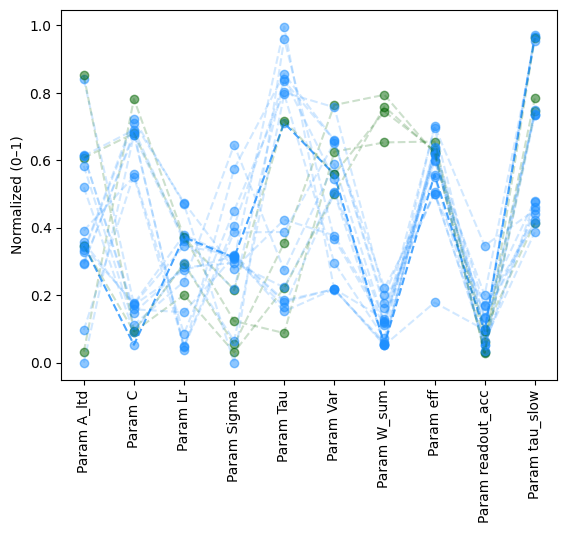

In [12]:
N_BEST = 20
for i in range(N_BEST):
    color = 'dodgerblue'
    
    # if df_normed_sorted.iloc[i]['Param Var'] > 0.6:
    #     color = 'coral'
    if df.iloc[i]['Param W_sum norm'] > 0.5:
        color = 'darkgreen'
    
    plt.scatter([i for i in range(len(params_norm))], df.iloc[i][params_norm].values, alpha=0.5, color=color)
   
    line_alpha = 0.2
    if i == 0:
        line_alpha = 0.8
        print(df.iloc[i][params])
    plt.plot(df.iloc[i][params_norm].values, alpha=line_alpha, linestyle='--', color=color)
        

plt.ylabel("Normalized (0–1)")
plt.xticks(ticks=[i for i in range(len(params))], labels=params, rotation=90)
plt.show()
